In [69]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
pd.set_option('display.max_columns',200)
pd.set_option('display.max_rows',200)

| data_format       | column_name                  | data_type | missing_values | description                                                                    |
|-------------------|------------------------------|-----------|----------------|--------------------------------------------------------------------------------|
| smart_meter_6hour | household_ID                 | object    | 0              | Unique household identifier                                                    |
| smart_meter_6hour | BRANCH                       | object    | 0              | Branch of the service provider                                                 |
| smart_meter_6hour | DEPOT                        | object    | 0              | From which depot of the branch the electricity was released from                                                                               |
| smart_meter_6hour | substation_ID                | object    | 0              | transformer id                                                                 |
| smart_meter_6hour | SUB_TYPE                     | object    | 0              | what type of phase such as single phase, 3 phase etc...                                                                               |
| smart_meter_6hour | E_BILLING                    | bool      | 0              | if electronic billing is enabled                                                                               |
| smart_meter_6hour | EXPORT                       | bool      | 0              | Energy exporting back to the grid or not                                       |
| smart_meter_6hour | DATE                         | object    | 0              | Date of the reading                                                            |
| smart_meter_6hour | TIME                         | object    | 0              | time of the reading                                                            |
| smart_meter_6hour | TOTAL_IMPORT (kWh)           | object    | 0              | Total Cumulative consumed energy units                                         |
| smart_meter_6hour | TOTAL_EXPORT (kWh)           | float64   | 0              | Total Cumulative generated energy units                                        |
| smart_meter_6hour | TOTAL_IMPORT - PV1 (kWh)     | float64   | 0              | Total consumed energy units as at 1st of the given month at 00:00 hrs          |
| smart_meter_6hour | TOTAL_EXPORT - PV1 (kWh)     | float64   | 0              | Total generated energy units as at 1st of the month at 00:00 hrs               |
| smart_meter_6hour | TR1_TOTAL_IMPORT (kWh)       | float64   | 0              | Cumulative consumed energy units for Day Time                                  |
| smart_meter_6hour | TR2_TOTAL_IMPORT (kWh)       | float64   | 0              | Cumulative consumed energy units for Peak Time                                 |
| smart_meter_6hour | TR3_TOTAL_IMPORT (kWh)       | float64   | 0              | Cumulative consumed energy units for off - Peak Time                           |
| smart_meter_6hour | TR1_TOTAL_EXPORT (kWh)       | float64   | 0              | Cumulative generated energy units for Day Time                                 |
| smart_meter_6hour | TR2_TOTAL_EXPORT (kWh)       | float64   | 0              | Cumulative generated energy units for Peak Time                                |
| smart_meter_6hour | TR3_TOTAL_EXPORT (kWh)       | float64   | 0              | Cumulative generated energy units for off-Peak Time                            |
| smart_meter_6hour | TR1_TOTAL_IMPORT - PV1 (kWh) | float64   | 0              | Day time consumed energy units as at 1st of the given month at 00:00 hrs       |
| smart_meter_6hour | TR2_TOTAL_IMPORT - PV1 (kWh) | float64   | 0              | Peak time consumed energy units as at 1st of the given month at 00:00 hrs      |
| smart_meter_6hour | TR3_TOTAL_IMPORT - PV1 (kWh) | float64   | 0              | Off-Peak time consumed energy units as at 1st of the given month at 00:00 hrs  |
| smart_meter_6hour | TR1_TOTAL_EXPORT - PV1 (kWh) | float64   | 0              | Day time generated energy units as at 1st of the given month at 00:00 hrs      |
| smart_meter_6hour | TR2_TOTAL_EXPORT - PV1 (kWh) | float64   | 0              | Peak time generated energy units as at 1st of the given month at 00:00 hrs     |
| smart_meter_6hour | TR3_TOTAL_EXPORT - PV1 (kWh) | float64   | 0              | Off-Peak time generated energy units as at 1st of the given month at 00:00 hrs |
| smart_meter_6hour | PHASE_A_CURRENT (A)          | float64   | 0              | In an N-phase system, a phase current is the current in one of the N separate phase conductors or windings.                                                                               |
| smart_meter_6hour | PHASE_A_VOLTAGE (V)          | float64   | 0              | In an N-phase system, a phase voltage is the voltage in one of the N separate phase conductors or windings.                                                                               |
| smart_meter_6hour | FREQUENCY (Hz)               | object    | 0              | utility frequency                                                                               |
| smart_meter_6hour | PHASE_B_CURRENT (A)          | float64   | 47493         | In an N-phase system, a phase current is the current in one of the N separate phase conductors or windings.                                                                                |
| smart_meter_6hour | PHASE_B_VOLTAGE (V)          | float64   | 47493         | In an N-phase system, a phase voltage is the voltage in one of the N separate phase conductors or windings                                                                               |
| smart_meter_6hour | PHASE_C_CURRENT (A)          | float64   | 47493         | In an N-phase system, a phase current is the current in one of the N separate phase conductors or windings.                                                                                |
| smart_meter_6hour | PHASE_C_VOLTAGE (V)          | float64   | 47493         | In an N-phase system, a phase voltage is the voltage in one of the N separate phase conductors or windings                                                                               |


Time series data of surveyed households

In [70]:
df = pd.read_csv("../data/processed1/combined_selection.csv")

In [71]:
df.head()

,household_ID,BRANCH,DEPOT,substation_ID,SUB_TYPE,E_BILLING,EXPORT,DATE,TIME,TOTAL_IMPORT (kWh),TOTAL_EXPORT (kWh),TOTAL_IMPORT - PV1 (kWh),TOTAL_EXPORT - PV1 (kWh),TR1_TOTAL_IMPORT (kWh),TR2_TOTAL_IMPORT (kWh),TR3_TOTAL_IMPORT (kWh),TR1_TOTAL_EXPORT (kWh),TR2_TOTAL_EXPORT (kWh),TR3_TOTAL_EXPORT (kWh),TR1_TOTAL_IMPORT - PV1 (kWh),TR2_TOTAL_IMPORT - PV1 (kWh),TR3_TOTAL_IMPORT - PV1 (kWh),TR1_TOTAL_EXPORT - PV1 (kWh),TR2_TOTAL_EXPORT - PV1 (kWh),TR3_TOTAL_EXPORT - PV1 (kWh),PHASE_A_CURRENT (A),PHASE_A_VOLTAGE (V),FREQUENCY (Hz),PHASE_B_CURRENT (A),PHASE_B_VOLTAGE (V),PHASE_C_CURRENT (A),PHASE_C_VOLTAGE (V)
0,ID2772,MORATUWA,MORATUWA SOUTH C.S.C,sub447,Anteleco - DLMS SinglePhase,False,False,2023-01-01,18:53:17,1092.5241,0.0,1090.8300,0.0,488.068,190.025,414.431,0.0,0.0,0.0,487.101,189.9830,413.746,0.0,0.0,0.0,0.720,232.7001,49.9500,NaN,NaN,NaN,NaN
1,ID3150,MORATUWA,MORATUWA NORTH C.S.C,sub501,Anteleco - DLMS SinglePhase,False,False,2023-01-01,18:55:21,1286.771,0.0,1284.6291,0.0,749.684,212.328,324.759,0.0,0.0,0.0,748.335,211.9940,324.300,0.0,0.0,0.0,3.864,231.9000,49.9000,NaN,NaN,NaN,NaN
2,ID1674,MORATUWA,MORATUWA SOUTH C.S.C,sub462,Anteleco - IEC SinglePhase,False,False,2023-01-01,18:58:02,516.81,0.0,515.1200,0.0,296.340,104.12,116.350,0.0,0.0,0.0,295.020,104.0800,116.020,0.0,0.0,0.0,0.609,216.2000,50.0000,NaN,NaN,NaN,NaN
3,ID1560,MORATUWA,MORATUWA SOUTH C.S.C,sub447,Anteleco - DLMS SinglePhase,False,False,2023-01-01,19:21:04,493.172,0.0,492.3910,0.0,294.063,107.101,92.007,0.0,0.0,0.0,293.295,107.0900,92.006,0.0,0.0,0.0,0.090,233.0000,49.9801,NaN,NaN,NaN,NaN
4,ID1663,MORATUWA,MORATUWA SOUTH C.S.C,sub128,Anteleco - DLMS SinglePhase,False,False,2023-01-01,19:22:00,1841.97,0.0,1838.7240,0.0,868.238,290.961,682.771,0.0,0.0,0.0,865.602,290.8811,682.241,0.0,0.0,0.0,0.722,231.6001,49.9101,NaN,NaN,NaN,NaN


In [72]:
# data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133713 entries, 0 to 2133712
Data columns (total 32 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   household_ID                  object 
 1   BRANCH                        object 
 2   DEPOT                         object 
 3   substation_ID                 object 
 4   SUB_TYPE                      object 
 5   E_BILLING                     bool   
 6   EXPORT                        bool   
 7   DATE                          object 
 8   TIME                          object 
 9   TOTAL_IMPORT (kWh)            object 
 10  TOTAL_EXPORT (kWh)            float64
 11  TOTAL_IMPORT - PV1 (kWh)      float64
 12  TOTAL_EXPORT - PV1 (kWh)      float64
 13  TR1_TOTAL_IMPORT (kWh)        float64
 14  TR2_TOTAL_IMPORT (kWh)        object 
 15  TR3_TOTAL_IMPORT (kWh)        float64
 16  TR1_TOTAL_EXPORT (kWh)        float64
 17  TR2_TOTAL_EXPORT (kWh)        float64
 18  TR3_TOTAL_EXPORT (kWh)

In [73]:
# check columns
df.columns

Index(['household_ID', 'BRANCH', 'DEPOT', 'substation_ID', 'SUB_TYPE',
       'E_BILLING', 'EXPORT', 'DATE', 'TIME', 'TOTAL_IMPORT (kWh)',
       'TOTAL_EXPORT (kWh)', 'TOTAL_IMPORT - PV1 (kWh)',
       'TOTAL_EXPORT - PV1 (kWh)', 'TR1_TOTAL_IMPORT (kWh)',
       'TR2_TOTAL_IMPORT (kWh)', 'TR3_TOTAL_IMPORT (kWh)',
       'TR1_TOTAL_EXPORT (kWh)', 'TR2_TOTAL_EXPORT (kWh)',
       'TR3_TOTAL_EXPORT (kWh)', 'TR1_TOTAL_IMPORT - PV1 (kWh)',
       'TR2_TOTAL_IMPORT - PV1 (kWh)', 'TR3_TOTAL_IMPORT - PV1 (kWh)',
       'TR1_TOTAL_EXPORT - PV1 (kWh)', 'TR2_TOTAL_EXPORT - PV1 (kWh)',
       'TR3_TOTAL_EXPORT - PV1 (kWh)', 'PHASE_A_CURRENT (A)',
       'PHASE_A_VOLTAGE (V)', 'FREQUENCY (Hz)', 'PHASE_B_CURRENT (A)',
       'PHASE_B_VOLTAGE (V)', 'PHASE_C_CURRENT (A)', 'PHASE_C_VOLTAGE (V)'],
      dtype='object')

In [74]:
# null check
df.isnull().sum()

household_ID                          0
BRANCH                                0
DEPOT                                 0
substation_ID                         0
SUB_TYPE                              0
E_BILLING                             0
EXPORT                                0
DATE                                  0
TIME                                  0
TOTAL_IMPORT (kWh)                    2
TOTAL_EXPORT (kWh)                    7
TOTAL_IMPORT - PV1 (kWh)              0
TOTAL_EXPORT - PV1 (kWh)              3
TR1_TOTAL_IMPORT (kWh)                4
TR2_TOTAL_IMPORT (kWh)                6
TR3_TOTAL_IMPORT (kWh)                3
TR1_TOTAL_EXPORT (kWh)                5
TR2_TOTAL_EXPORT (kWh)                2
TR3_TOTAL_EXPORT (kWh)                1
TR1_TOTAL_IMPORT - PV1 (kWh)          2
TR2_TOTAL_IMPORT - PV1 (kWh)          2
TR3_TOTAL_IMPORT - PV1 (kWh)          3
TR1_TOTAL_EXPORT - PV1 (kWh)          1
TR2_TOTAL_EXPORT - PV1 (kWh)          2
TR3_TOTAL_EXPORT - PV1 (kWh)          0


To fill in the average value, we must first see whether the data has an outlier or not. If there are outliers from the data, then the mean or median of the data will be used therefore it was decided to check the mean and median of each column containing missing data with the max and min values.

In [75]:
# descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TOTAL_EXPORT (kWh),2133706.0,1426.511390,5528.656437,0.000,0.00000,0.0000,0.0000,96070.2770
TOTAL_IMPORT - PV1 (kWh),2133713.0,2757.335876,2649.868021,0.000,1318.07400,2147.4440,3345.8680,39857.2300
TOTAL_EXPORT - PV1 (kWh),2133710.0,1392.717011,5429.591404,0.000,0.00000,0.0000,0.0000,93851.1180
TR1_TOTAL_IMPORT (kWh),2133709.0,1284.550905,1373.650700,0.000,628.29000,1025.7850,1579.0431,41128.2460
TR3_TOTAL_IMPORT (kWh),2133710.0,913.129588,1125.441003,0.000,376.02825,640.7245,1045.9210,19556.8070
TR1_TOTAL_EXPORT (kWh),2133708.0,1420.047581,5506.835876,0.000,0.00000,0.0000,0.0000,96070.2730
TR2_TOTAL_EXPORT (kWh),2133711.0,1.792462,37.109624,0.000,0.00000,0.0000,0.0000,1091.3700
TR3_TOTAL_EXPORT (kWh),2133712.0,4.669944,82.538417,0.000,0.00000,0.0000,0.0000,1878.2900
TR1_TOTAL_IMPORT - PV1 (kWh),2133711.0,1257.253272,1353.954015,0.000,608.55200,1001.0820,1547.9030,39857.1950
TR2_TOTAL_IMPORT - PV1 (kWh),2133711.0,608.070259,668.674581,0.000,269.30300,447.7440,712.8930,12100.3181


In [76]:
df.shape

(2133713, 32)

### Preprocessing and Cleaning

In [77]:
df['TOTAL_IMPORT (kWh)'] = (
    df['TOTAL_IMPORT (kWh)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

In [78]:
df['TOTAL_IMPORT (kWh)'] = pd.to_numeric(
    df['TOTAL_IMPORT (kWh)'],
    errors='coerce'
)

In [79]:
bad = df[df['TOTAL_IMPORT (kWh)'].isna()]

In [80]:
bad.head()

,household_ID,BRANCH,DEPOT,substation_ID,SUB_TYPE,E_BILLING,EXPORT,DATE,TIME,TOTAL_IMPORT (kWh),TOTAL_EXPORT (kWh),TOTAL_IMPORT - PV1 (kWh),TOTAL_EXPORT - PV1 (kWh),TR1_TOTAL_IMPORT (kWh),TR2_TOTAL_IMPORT (kWh),TR3_TOTAL_IMPORT (kWh),TR1_TOTAL_EXPORT (kWh),TR2_TOTAL_EXPORT (kWh),TR3_TOTAL_EXPORT (kWh),TR1_TOTAL_IMPORT - PV1 (kWh),TR2_TOTAL_IMPORT - PV1 (kWh),TR3_TOTAL_IMPORT - PV1 (kWh),TR1_TOTAL_EXPORT - PV1 (kWh),TR2_TOTAL_EXPORT - PV1 (kWh),TR3_TOTAL_EXPORT - PV1 (kWh),PHASE_A_CURRENT (A),PHASE_A_VOLTAGE (V),FREQUENCY (Hz),PHASE_B_CURRENT (A),PHASE_B_VOLTAGE (V),PHASE_C_CURRENT (A),PHASE_C_VOLTAGE (V)
206722,ID0352,MORATUWA,MORATUWA SOUTH C.S.C,sub450,Anteleco - DLMS SinglePhase,False,False,2023-03-30,18:44:08:313,NaN,NaN,1572.5241,0.0,NaN,NaN,NaN,NaN,NaN,0.0,877.037,283.1370,412.350,0.0,0.0,0.0,0.835,231.2001,49.9801,NaN,NaN,NaN,NaN
1331583,ID0210,NUGEGODA,BORALASGAMUWA,sub660,Anteleco - DLMS 3Phase,False,False,2023-12-07,18:41:07,NaN,0.00,6228.6770,0.0,2452.1331,1076.0911,2765.859,0.00,0.0,0.0,2430.065,1064.9371,2733.675,0.0,0.0,0.0,0.240,226.9000,50.0800,0.049,231.2001,0.257,231.6001
1973515,ID2422,NUGEGODA,NUGEGODA,sub209,Anteleco - IEC 3Phase,False,True,2024-08-12,01:07:44,NaN,14253.54,15439.3300,14186.7,4870.2600,5014.87,5641.250,14253.54,0.0,0.0,4844.220,4990.0200,5605.090,14186.7,0.0,0.0,0.887,227.9700,50.0900,0.984,232.3600,0.448,226.1500


Since TOTAL_IMPORT (kWh) is the total cumulative consumed energy units missing values were foward filled.

In [81]:
df['TOTAL_IMPORT (kWh)'] = df.groupby('household_ID')['TOTAL_IMPORT (kWh)']\
    .transform(lambda x: x.ffill())

In [82]:
df['TR2_TOTAL_IMPORT (kWh)'] = (
    df['TR2_TOTAL_IMPORT (kWh)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

In [83]:
df['TR2_TOTAL_IMPORT (kWh)'] = pd.to_numeric(
    df['TR2_TOTAL_IMPORT (kWh)'],
    errors='coerce'
)

In [84]:
bad1 = df[df['TR2_TOTAL_IMPORT (kWh)'].isna()]

In [85]:
bad1.head()

,household_ID,BRANCH,DEPOT,substation_ID,SUB_TYPE,E_BILLING,EXPORT,DATE,TIME,TOTAL_IMPORT (kWh),TOTAL_EXPORT (kWh),TOTAL_IMPORT - PV1 (kWh),TOTAL_EXPORT - PV1 (kWh),TR1_TOTAL_IMPORT (kWh),TR2_TOTAL_IMPORT (kWh),TR3_TOTAL_IMPORT (kWh),TR1_TOTAL_EXPORT (kWh),TR2_TOTAL_EXPORT (kWh),TR3_TOTAL_EXPORT (kWh),TR1_TOTAL_IMPORT - PV1 (kWh),TR2_TOTAL_IMPORT - PV1 (kWh),TR3_TOTAL_IMPORT - PV1 (kWh),TR1_TOTAL_EXPORT - PV1 (kWh),TR2_TOTAL_EXPORT - PV1 (kWh),TR3_TOTAL_EXPORT - PV1 (kWh),PHASE_A_CURRENT (A),PHASE_A_VOLTAGE (V),FREQUENCY (Hz),PHASE_B_CURRENT (A),PHASE_B_VOLTAGE (V),PHASE_C_CURRENT (A),PHASE_C_VOLTAGE (V)
206722,ID0352,MORATUWA,MORATUWA SOUTH C.S.C,sub450,Anteleco - DLMS SinglePhase,False,False,2023-03-30,18:44:08:313,1659.877,NaN,1572.5241,0.000,NaN,NaN,NaN,NaN,NaN,0.00,877.0370,283.1370,412.350,0.000,0.00,0.00,0.835,231.2001,49.9801,NaN,NaN,NaN,NaN
601122,ID2069,MORATUWA,MORATUWA SOUTH C.S.C,sub472,Anteleco - DLMS SinglePhase,False,False,2023-06-09,05:49:29,1950.582,0.000,1921.2960,0.000,877.8481,NaN,618.2091,0.000,0.00,0.00,865.5361,447.1741,608.585,0.000,0.00,0.00,0.660,232.1001,49.8800,NaN,NaN,NaN,NaN
763211,ID3095,MORATUWA,PANADURA C.S.C,sub330,Anteleco - DLMS 3Phase,False,True,2023-07-14,18:37:41,2172.178,20765.101,2103.3410,20330.889,613.5311,NaN,667.2130,20765.101,0.00,0.00,589.7521,864.3871,649.202,20330.889,0.00,0.00,0.397,232.6001,49.9900,0.396,234.7001,1.3881,234.40
858373,ID2167,NUGEGODA,NUGEGODA,sub610,Anteleco - IEC 3Phase,False,True,2023-08-06,18:32:29,22410.290,29142.950,22345.6800,29038.510,6009.8300,NaN,10570.5700,27037.850,702.47,1402.62,5993.3400,5818.4000,10533.940,26933.410,702.47,1402.62,0.891,231.3100,50.1100,4.382,226.1300,13.2250,220.35
1085327,ID1781,MORATUWA,MORATUWA NORTH C.S.C,sub513,Anteleco - DLMS SinglePhase,False,False,2023-10-03,18:58:22,2964.736,0.000,2937.4090,0.000,1564.7980,NaN,897.7770,0.000,0.00,0.00,1549.3950,499.0100,889.004,0.000,0.00,0.00,5.612,231.4000,50.0000,NaN,NaN,NaN,NaN


Since TR2_TOTAL_IMPORT (kWh) is the cumulative consumed energy units at peak time missing values were foward filled.

In [86]:
df['TR2_TOTAL_IMPORT (kWh)'] = df.groupby('household_ID')['TR2_TOTAL_IMPORT (kWh)']\
    .transform(lambda x: x.ffill())

18:44:08:313 type readings in time to standard readings of 18:44:08

In [87]:
df['TIME'] = df['TIME'].str.replace(r':\d+$', '', regex=True)

Since the only columns with missing data are PHASE_B_CURRENT (A),
PHASE_B_VOLTAGE (V),PHASE_C_CURRENT (A), PHASE_VOLTAGE (V) with 1978772 out of 2133713 rows which are more than 80% of the data these columns were removed.

In [88]:
df = df.drop(columns=[
    'PHASE_B_CURRENT (A)',
    'PHASE_B_VOLTAGE (V)',
    'PHASE_C_CURRENT (A)',
    'PHASE_C_VOLTAGE (V)'
])

Boolean Values

Boolean values of and "EXPORT" which says whether energy is exported back to the grid or not and "E_BILLING" is whether the bill was generated electronically or not.

"EXPORT" flag was removed because the study is to forecast the demand for electricity and "EBILLING" flag was removed because it may provide unnecessary noise to the forecasting.

In [89]:
df = df.drop(columns=['E_BILLING', 'EXPORT'])

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133713 entries, 0 to 2133712
Data columns (total 26 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   household_ID                  object 
 1   BRANCH                        object 
 2   DEPOT                         object 
 3   substation_ID                 object 
 4   SUB_TYPE                      object 
 5   DATE                          object 
 6   TIME                          object 
 7   TOTAL_IMPORT (kWh)            float64
 8   TOTAL_EXPORT (kWh)            float64
 9   TOTAL_IMPORT - PV1 (kWh)      float64
 10  TOTAL_EXPORT - PV1 (kWh)      float64
 11  TR1_TOTAL_IMPORT (kWh)        float64
 12  TR2_TOTAL_IMPORT (kWh)        float64
 13  TR3_TOTAL_IMPORT (kWh)        float64
 14  TR1_TOTAL_EXPORT (kWh)        float64
 15  TR2_TOTAL_EXPORT (kWh)        float64
 16  TR3_TOTAL_EXPORT (kWh)        float64
 17  TR1_TOTAL_IMPORT - PV1 (kWh)  float64
 18  TR2_TOTAL_IMPORT - PV1

In [91]:
df.shape

(2133713, 26)

Categorical Variables

In [92]:
df_cat = df.select_dtypes(include = 'object').copy()
df_cat = df_cat.drop(columns=['DATE', 'TIME'])

In [93]:
df_cat.head()

,household_ID,BRANCH,DEPOT,substation_ID,SUB_TYPE
0,ID2772,MORATUWA,MORATUWA SOUTH C.S.C,sub447,Anteleco - DLMS SinglePhase
1,ID3150,MORATUWA,MORATUWA NORTH C.S.C,sub501,Anteleco - DLMS SinglePhase
2,ID1674,MORATUWA,MORATUWA SOUTH C.S.C,sub462,Anteleco - IEC SinglePhase
3,ID1560,MORATUWA,MORATUWA SOUTH C.S.C,sub447,Anteleco - DLMS SinglePhase
4,ID1663,MORATUWA,MORATUWA SOUTH C.S.C,sub128,Anteleco - DLMS SinglePhase


In [94]:
df_cat['household_ID'].unique()

array(['ID2772', 'ID3150', 'ID1674', ..., 'ID1778', 'ID2233', 'ID3470'],
      shape=(1385,), dtype=object)

In [95]:
df_cat['BRANCH'].unique()

array(['MORATUWA', 'KALUTARA', 'NUGEGODA', 'KELANIYA', 'GALLE', 'KOTTE'],
      dtype=object)

Which depot of the branch is the electricity sent from

In [96]:
df_cat['DEPOT'].unique()

array(['MORATUWA SOUTH C.S.C', 'MORATUWA NORTH C.S.C', 'PANADURA C.S.C',
       'KALUTHARA', 'ALUTHGAMA', 'KESELWATTA C.S.C', 'BORALASGAMUWA',
       'DALUGAMA', 'KANDANA', 'MAHARAGAMA', 'NUGEGODA', 'AMBALANGODA',
       'WATTALA', 'MAHARA', 'PAYAGALA', 'KOTIKAWATTA'], dtype=object)

Its the station from which the electricity is sent from.

In [97]:
df_cat['substation_ID'].unique()

array(['sub447', 'sub501', 'sub462', 'sub128', 'sub584', 'sub542',
       'sub450', 'sub522', 'sub435', 'sub427', 'sub554', 'sub526',
       'sub523', 'sub550', 'sub479', 'sub558', 'sub583', 'sub426',
       'sub485', 'sub341', 'sub365', 'sub322', 'sub376', 'sub123',
       'sub477', 'sub108', 'sub317', 'sub327', 'sub359', 'sub377',
       'sub381', 'sub325', 'sub379', 'sub360', 'sub112', 'sub368',
       'sub331', 'sub326', 'sub102', 'sub471', 'sub114', 'sub472',
       'sub461', 'sub464', 'sub470', 'sub432', 'sub433', 'sub425',
       'sub443', 'sub489', 'sub438', 'sub440', 'sub133', 'sub454',
       'sub484', 'sub452', 'sub446', 'sub490', 'sub468', 'sub441',
       'sub483', 'sub459', 'sub439', 'sub430', 'sub487', 'sub101',
       'sub466', 'sub445', 'sub560', 'sub582', 'sub564', 'sub511',
       'sub503', 'sub540', 'sub417', 'sub297', 'sub394', 'sub402',
       'sub406', 'sub412', 'sub555', 'sub520', 'sub286', 'sub527',
       'sub106', 'sub506', 'sub512', 'sub541', 'sub502', 'sub5

In [98]:
df_cat['SUB_TYPE'].unique()

array(['Anteleco - DLMS SinglePhase', 'Anteleco - IEC SinglePhase',
       'Anteleco - DLMS 3Phase', 'Anteleco - IEC 3Phase'], dtype=object)

##### Visual Exploration

<Axes: xlabel='BRANCH', ylabel='count'>

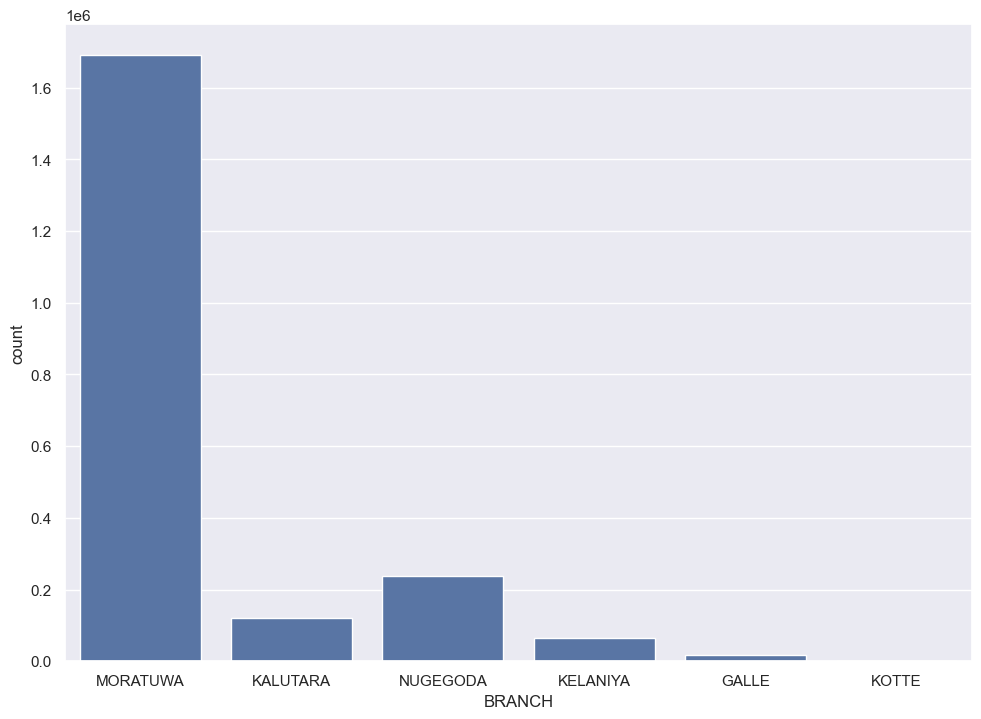

In [99]:
sns.countplot(data = df_cat, x = 'BRANCH')

<Axes: xlabel='SUB_TYPE', ylabel='count'>

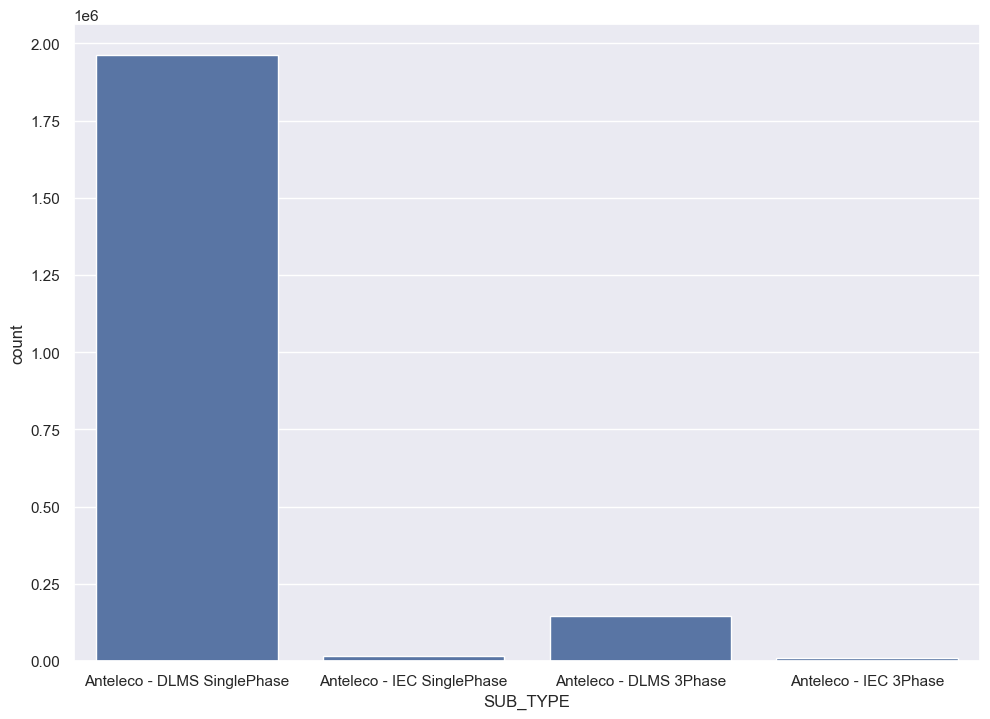

In [100]:
sns.countplot(data = df_cat, x = 'SUB_TYPE')

substation_id and DEPOT were removed as they represent low level infrastructure identifiers that do not provide any meaningful exploratory value for household level consumption forecasting.

In [101]:
df = df.drop(columns=['DEPOT', 'substation_ID'])

Numerical Variables

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133713 entries, 0 to 2133712
Data columns (total 24 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   household_ID                  object 
 1   BRANCH                        object 
 2   SUB_TYPE                      object 
 3   DATE                          object 
 4   TIME                          object 
 5   TOTAL_IMPORT (kWh)            float64
 6   TOTAL_EXPORT (kWh)            float64
 7   TOTAL_IMPORT - PV1 (kWh)      float64
 8   TOTAL_EXPORT - PV1 (kWh)      float64
 9   TR1_TOTAL_IMPORT (kWh)        float64
 10  TR2_TOTAL_IMPORT (kWh)        float64
 11  TR3_TOTAL_IMPORT (kWh)        float64
 12  TR1_TOTAL_EXPORT (kWh)        float64
 13  TR2_TOTAL_EXPORT (kWh)        float64
 14  TR3_TOTAL_EXPORT (kWh)        float64
 15  TR1_TOTAL_IMPORT - PV1 (kWh)  float64
 16  TR2_TOTAL_IMPORT - PV1 (kWh)  float64
 17  TR3_TOTAL_IMPORT - PV1 (kWh)  float64
 18  TR1_TOTAL_EXPORT - PV1

In [103]:
numeric_df = df.select_dtypes(include='float64')
correlations = numeric_df.corr()


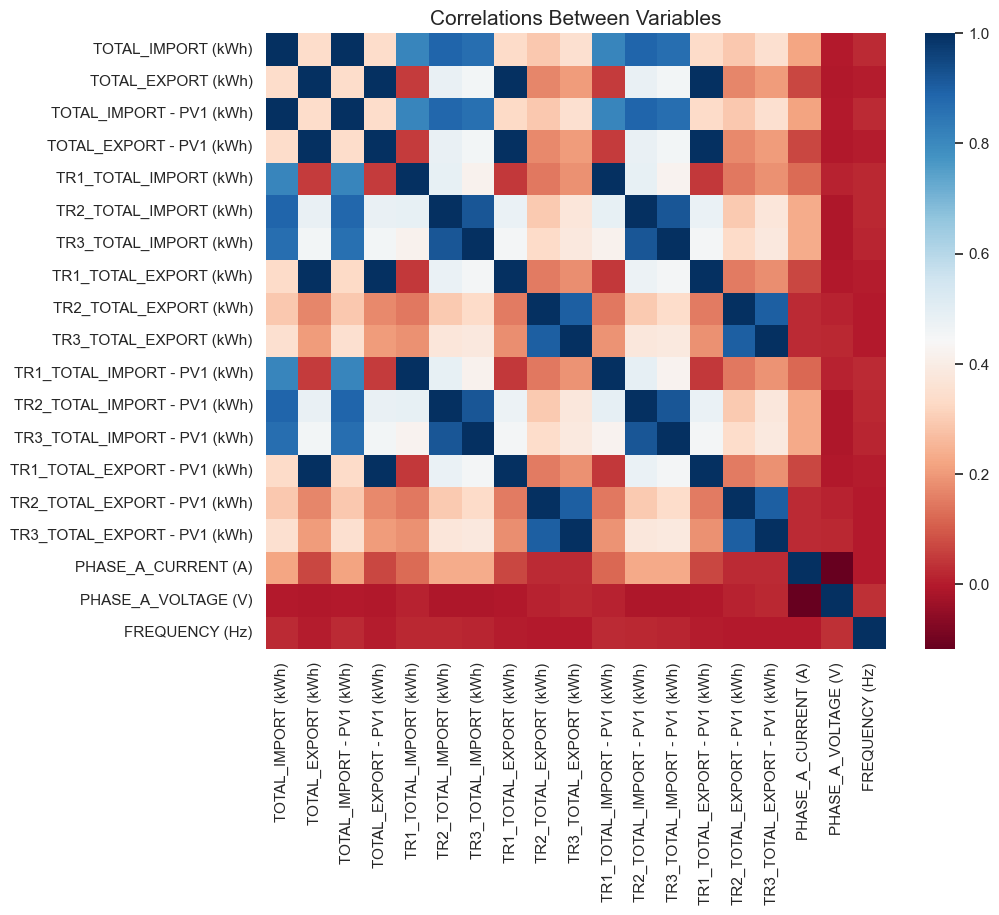

In [104]:
plt.figure(figsize=(10,8))
sns.heatmap(correlations, cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.savefig("correlation_matrix.png")
plt.show()

Electrical features such as PHASE_A_CURRENT and PHASE_A_VOLTAGE were removed due to inconsistency in representation across different household configurations. While these variables fully describe single-phase systems, they only capture partial information for three-phase systems. This discrepancy may introduce bias and reduce model interpretability. Instead, the SUB_TYPE feature was retained to represent the electrical configuration of each household, ensuring consistent and explainable modeling.

In [105]:
df = df.drop(columns=['PHASE_A_CURRENT (A)','PHASE_A_VOLTAGE (V)'])

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133713 entries, 0 to 2133712
Data columns (total 22 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   household_ID                  object 
 1   BRANCH                        object 
 2   SUB_TYPE                      object 
 3   DATE                          object 
 4   TIME                          object 
 5   TOTAL_IMPORT (kWh)            float64
 6   TOTAL_EXPORT (kWh)            float64
 7   TOTAL_IMPORT - PV1 (kWh)      float64
 8   TOTAL_EXPORT - PV1 (kWh)      float64
 9   TR1_TOTAL_IMPORT (kWh)        float64
 10  TR2_TOTAL_IMPORT (kWh)        float64
 11  TR3_TOTAL_IMPORT (kWh)        float64
 12  TR1_TOTAL_EXPORT (kWh)        float64
 13  TR2_TOTAL_EXPORT (kWh)        float64
 14  TR3_TOTAL_EXPORT (kWh)        float64
 15  TR1_TOTAL_IMPORT - PV1 (kWh)  float64
 16  TR2_TOTAL_IMPORT - PV1 (kWh)  float64
 17  TR3_TOTAL_IMPORT - PV1 (kWh)  float64
 18  TR1_TOTAL_EXPORT - PV1

TOTAL_EXPORT (kWh), TOTAL_IMPORT - PV1 (kWh), TOTAL_EXPORT - PV1 (kWh)
and ALL TR*_TOTAL_* columns are derived from the same measurement time and represents future or parallel information since these features are related to energy export and transformer level, they were removed to prevent data leakage as they are highly derived from or correlated with the target variable which would lead to an overly optimistic model performance and would be better for explainability. 

In [107]:
df = df.drop(columns=[
    'TOTAL_EXPORT (kWh)',
    'TOTAL_IMPORT - PV1 (kWh)',
    'TOTAL_EXPORT - PV1 (kWh)',
    'TR1_TOTAL_IMPORT (kWh)',
    'TR2_TOTAL_IMPORT (kWh)',
    'TR3_TOTAL_IMPORT (kWh)',
    'TR1_TOTAL_EXPORT (kWh)',
    'TR2_TOTAL_EXPORT (kWh)',
    'TR3_TOTAL_EXPORT (kWh)',
    'TR1_TOTAL_IMPORT - PV1 (kWh)',
    'TR2_TOTAL_IMPORT - PV1 (kWh)',
    'TR3_TOTAL_IMPORT - PV1 (kWh)',
    'TR1_TOTAL_EXPORT - PV1 (kWh)',
    'TR2_TOTAL_EXPORT - PV1 (kWh)',
    'TR3_TOTAL_EXPORT - PV1 (kWh)'
])

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133713 entries, 0 to 2133712
Data columns (total 7 columns):
 #   Column              Dtype  
---  ------              -----  
 0   household_ID        object 
 1   BRANCH              object 
 2   SUB_TYPE            object 
 3   DATE                object 
 4   TIME                object 
 5   TOTAL_IMPORT (kWh)  float64
 6   FREQUENCY (Hz)      float64
dtypes: float64(2), object(5)
memory usage: 114.0+ MB


In [109]:
df = df.sort_values(['household_ID', 'DATE', 'TIME'])

In [110]:
df.rename(columns={'household_ID': 'household_ID', 'BRANCH': 'branch', 'SUB_TYPE':'sub_type', 'DATE':'date', 'TIME': 'time', 'TOTAL_IMPORT (kWh)': 'total_import(kWh)', 'FREQUENCY (Hz)': 'frequency(Hz)'}, inplace=True)

In [111]:
df = df.copy()

df['datetime'] = pd.to_datetime(
    df['date'].astype(str).str.strip() + ' ' +
    df['time'].astype(str).str.strip(),
    errors='coerce'
)

In [112]:
df.loc[[206722, 802554, 225731], ['date', 'time', 'datetime']]

,date,time,datetime
206722,2023-03-30,18:44:08,NaT
802554,2023-07-23,01:07:30,NaT
225731,2023-04-04,18:58:59,NaT


In [113]:
print(df[['date','time']].dtypes)

date    object
time    object
dtype: object


In [114]:
df.loc[[206722], 'date'].values, df.loc[[206722], 'time'].values

(array(['2023-03-30'], dtype=object), array(['18:44:08'], dtype=object))

In [115]:
pd.to_datetime('2023-03-30 18:44:08')

Timestamp('2023-03-30 18:44:08')

In [116]:
bad = df[df['datetime'].isna()]
bad.head()

,household_ID,branch,sub_type,date,time,total_import(kWh),frequency(Hz),datetime
206722,ID0352,MORATUWA,Anteleco - DLMS SinglePhase,2023-03-30,18:44:08,1659.877,49.9801,NaT
802554,ID1736,MORATUWA,Anteleco - DLMS SinglePhase,2023-07-23,01:07:30,2708.597,50.0200,NaT
225731,ID3201,MORATUWA,Anteleco - DLMS SinglePhase,2023-04-04,18:58:59,964.769,50.1300,NaT


In [117]:
df['datetime'] = pd.to_datetime(
    df['date'].str.strip() + ' ' + df['time'].str.strip(),
    errors='coerce'
)

In [118]:
bad = df[df['datetime'].isna()]
bad.head()

,household_ID,branch,sub_type,date,time,total_import(kWh),frequency(Hz),datetime
206722,ID0352,MORATUWA,Anteleco - DLMS SinglePhase,2023-03-30,18:44:08,1659.877,49.9801,NaT
802554,ID1736,MORATUWA,Anteleco - DLMS SinglePhase,2023-07-23,01:07:30,2708.597,50.0200,NaT
225731,ID3201,MORATUWA,Anteleco - DLMS SinglePhase,2023-04-04,18:58:59,964.769,50.1300,NaT


In [119]:
df = df.copy()

df['datetime'] = df.apply(
    lambda row: pd.to_datetime(
        f"{row['date']} {row['time']}",
        errors='coerce'
    ),
    axis=1
)

In [120]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [122]:
df = df.sort_values(by=['household_ID', 'datetime'])

In [123]:
df.head()

,household_ID,branch,sub_type,date,time,total_import(kWh),frequency(Hz),datetime
68796,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,02:29,402.916,50.1400,2023-02-01 02:29:00
68776,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,06:21,403.764,50.0000,2023-02-01 06:21:00
72982,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,01:20,407.743,50.1201,2023-02-02 01:20:00
73033,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,06:26,408.860,50.1700,2023-02-02 06:26:00
75794,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-03,01:25,413.213,50.1700,2023-02-03 01:25:00


In [124]:
df['consumption'] = df.groupby('household_ID')['total_import(kWh)'].diff().fillna(0)

In [125]:
df.loc[df['consumption'] < 0, 'consumption'] = 0

<Axes: xlabel='datetime'>

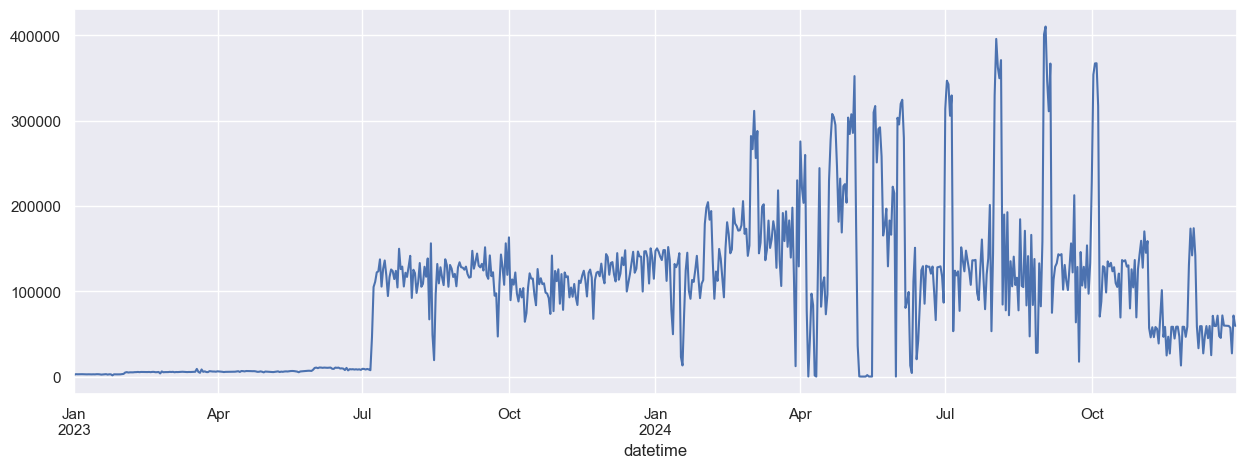

In [126]:
df.set_index('datetime').resample('D')['consumption'].sum().plot(figsize=(15,5))

In [127]:
df = df.drop(columns=['total_import(kWh)'])

In [128]:
df['frequency(Hz)'] = pd.to_numeric(df['frequency(Hz)'], errors='coerce')

In [129]:
df.head()

,household_ID,branch,sub_type,date,time,frequency(Hz),datetime,consumption
68796,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,02:29,50.1400,2023-02-01 02:29:00,0.000
68776,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,06:21,50.0000,2023-02-01 06:21:00,0.848
72982,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,01:20,50.1201,2023-02-02 01:20:00,3.979
73033,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,06:26,50.1700,2023-02-02 06:26:00,1.117
75794,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-03,01:25,50.1700,2023-02-03 01:25:00,4.353


Since the frequency is approximately constant 49 - 50 Hz it was dropped due to very low variation

In [130]:
df = df.drop(columns=['frequency(Hz)'])

In [131]:
df = df.set_index('datetime')

In [132]:
df.head()

,household_ID,branch,sub_type,date,time,consumption
datetime,,,,,,
2023-02-01 02:29:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,02:29,0.000
2023-02-01 06:21:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,06:21,0.848
2023-02-02 01:20:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,01:20,3.979
2023-02-02 06:26:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,06:26,1.117
2023-02-03 01:25:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-03,01:25,4.353


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2133713 entries, 2023-02-01 02:29:00 to 2024-11-12 01:26:00
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   household_ID  object 
 1   branch        object 
 2   sub_type      object 
 3   date          object 
 4   time          object 
 5   consumption   float64
dtypes: float64(1), object(5)
memory usage: 114.0+ MB


In [134]:
df = df.reset_index()

In [135]:
df.head()

,datetime,household_ID,branch,sub_type,date,time,consumption
0,2023-02-01 02:29:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,02:29,0.000
1,2023-02-01 06:21:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-01,06:21,0.848
2,2023-02-02 01:20:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,01:20,3.979
3,2023-02-02 06:26:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-02,06:26,1.117
4,2023-02-03 01:25:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-02-03,01:25,4.353


In [136]:
df.to_csv("../data/processed1/processed_selection.csv", index=False)